# Full A-SCI Simulation Study

  N=2000  T=20  MC runs=1000
  Initial wealth: BOTH groups ~ N(0.65, 0.12²)
  Structural A: Adv ~ N(1.0, 0.12²)  Marg ~ N(0.4, 0.12²)

--- Single illustrative run ---


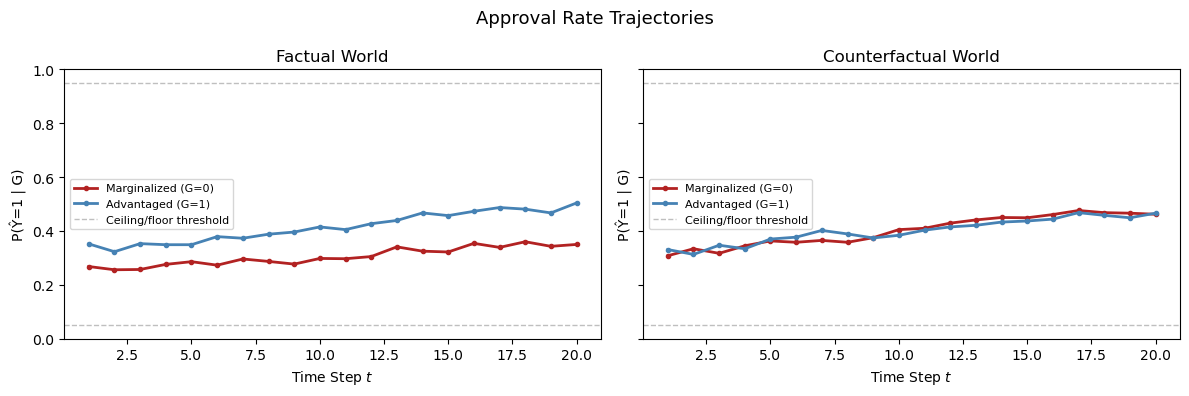

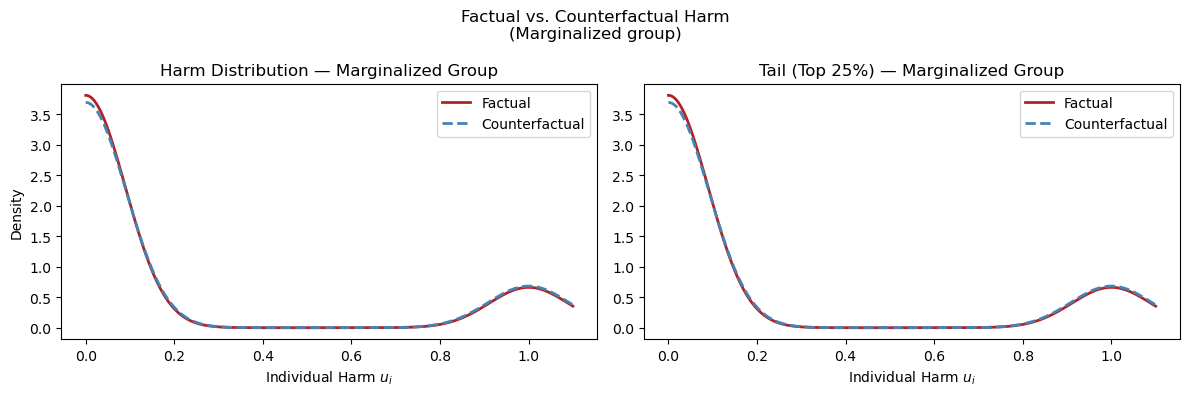


  Tail Analysis — Marginalized Group
  P75: Factual=0.0000  CF=0.0000  Excess tail mass=-0.0080
  P90: Factual=1.0000  CF=1.0000  Excess tail mass=+0.0000
  P95: Factual=1.0000  CF=1.0000  Excess tail mass=+0.0000
  P99: Factual=1.0000  CF=1.0000  Excess tail mass=+0.0000

  CVaR_95 — Factual: 1.0000 | CF: 1.0000 | Gap: +0.0000


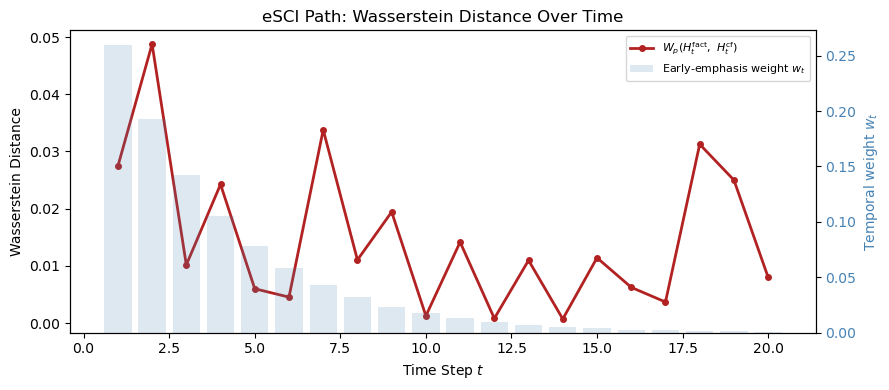


--- Monte Carlo simulation ---
  Completed run 10/1000
  Completed run 20/1000
  Completed run 30/1000
  Completed run 40/1000
  Completed run 50/1000
  Completed run 60/1000
  Completed run 70/1000
  Completed run 80/1000
  Completed run 90/1000
  Completed run 100/1000
  Completed run 110/1000
  Completed run 120/1000
  Completed run 130/1000
  Completed run 140/1000
  Completed run 150/1000
  Completed run 160/1000
  Completed run 170/1000
  Completed run 180/1000
  Completed run 190/1000
  Completed run 200/1000
  Completed run 210/1000
  Completed run 220/1000
  Completed run 230/1000
  Completed run 240/1000
  Completed run 250/1000
  Completed run 260/1000
  Completed run 270/1000
  Completed run 280/1000
  Completed run 290/1000
  Completed run 300/1000
  Completed run 310/1000
  Completed run 320/1000
  Completed run 330/1000
  Completed run 340/1000
  Completed run 350/1000
  Completed run 360/1000
  Completed run 370/1000
  Completed run 380/1000
  Completed run 390/1000
  

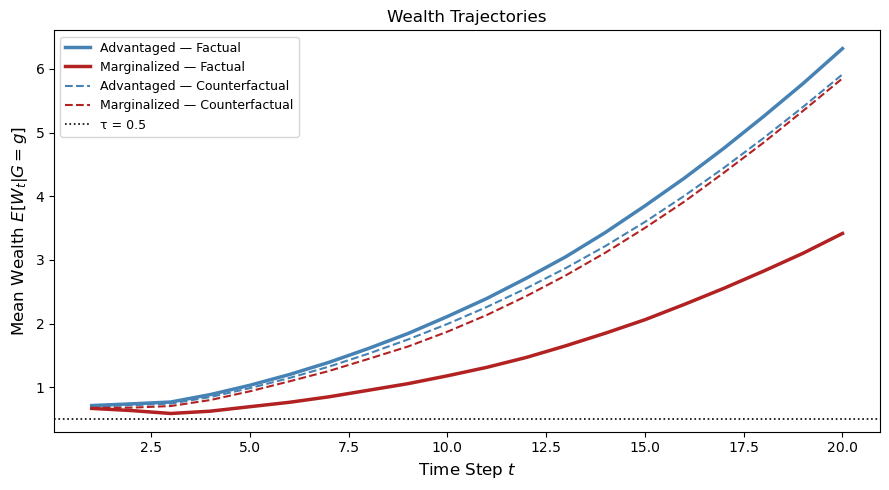

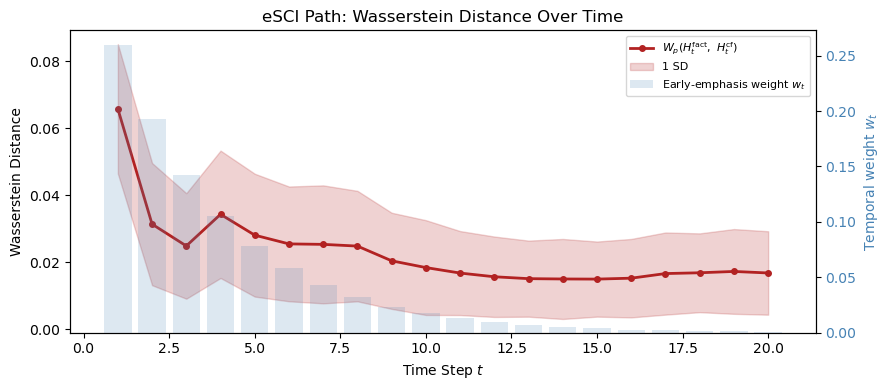

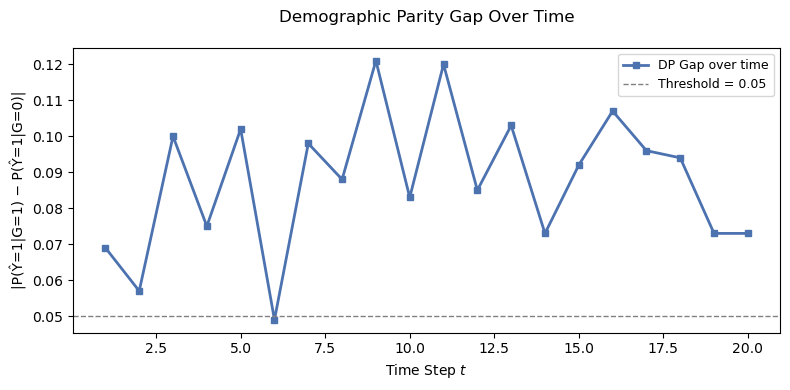


  All Metrics
  (mean ± SD over Monte Carlo runs)
  dSCI  (Wasserstein at t=T)              : 0.0167 ± 0.0125
  eSCI_path (early-emphasis)              : 0.0374 ± 0.0084
  CVaR_95 gap  (factual − counterfactual) : 0.0000 ± 0.0000
-----------------------------------------------------------------
  STATIC METRICS  (cross-sectional, evaluated at t=T)
  Demographic Parity Gap                  : 0.1063 ± 0.0216
  Equalized Odds Gap                      : 0.0531 ± 0.0221
-----------------------------------------------------------------
  LIU ET AL. (2018) DYNAMIC COMPARATOR
  Δμ_marginalized (wealth change t=0→T)   : 2.7833 ± 0.2201
  Δμ_advantaged   (wealth change t=0→T)   : 5.2357 ± 0.2800

  Both groups initialized at identical W and C distributions.
  Any non-zero metric value therefore reflects inequality
  generated ENTIRELY by the structural attribute A and the
  algorithmic feedback loop — not by initial conditions.

  DP Gap at t=T detects the terminal approval-rate divergence
  bu

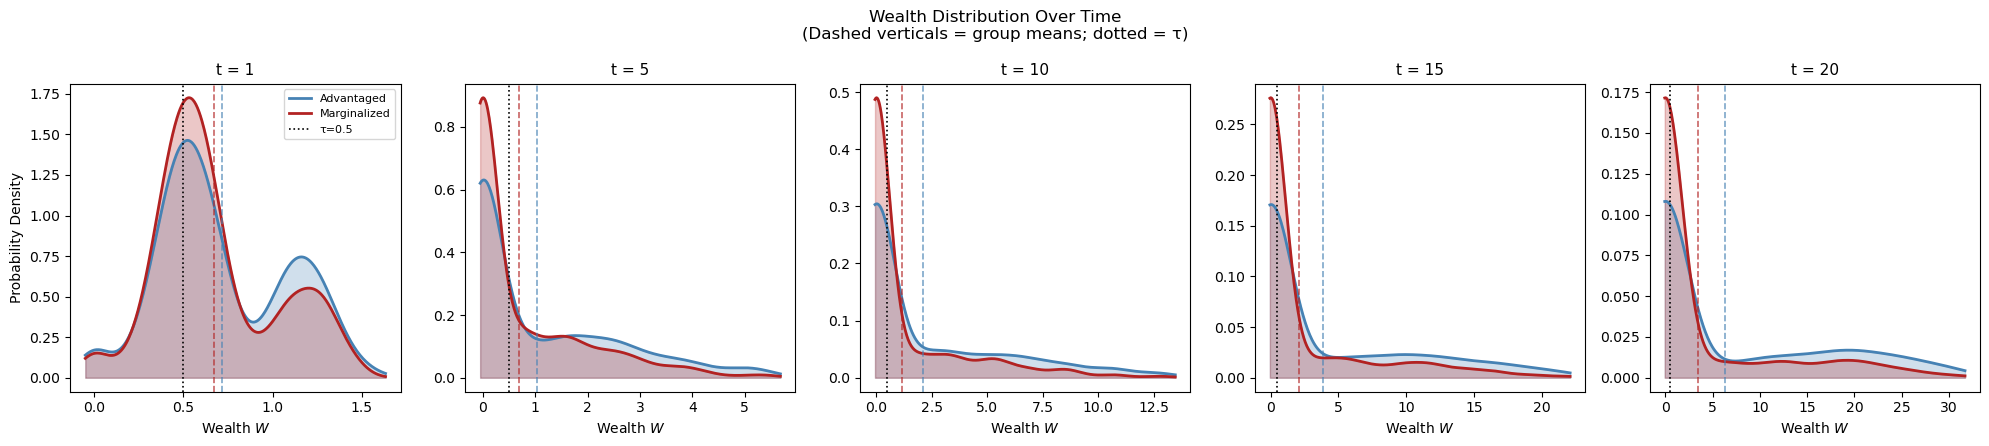

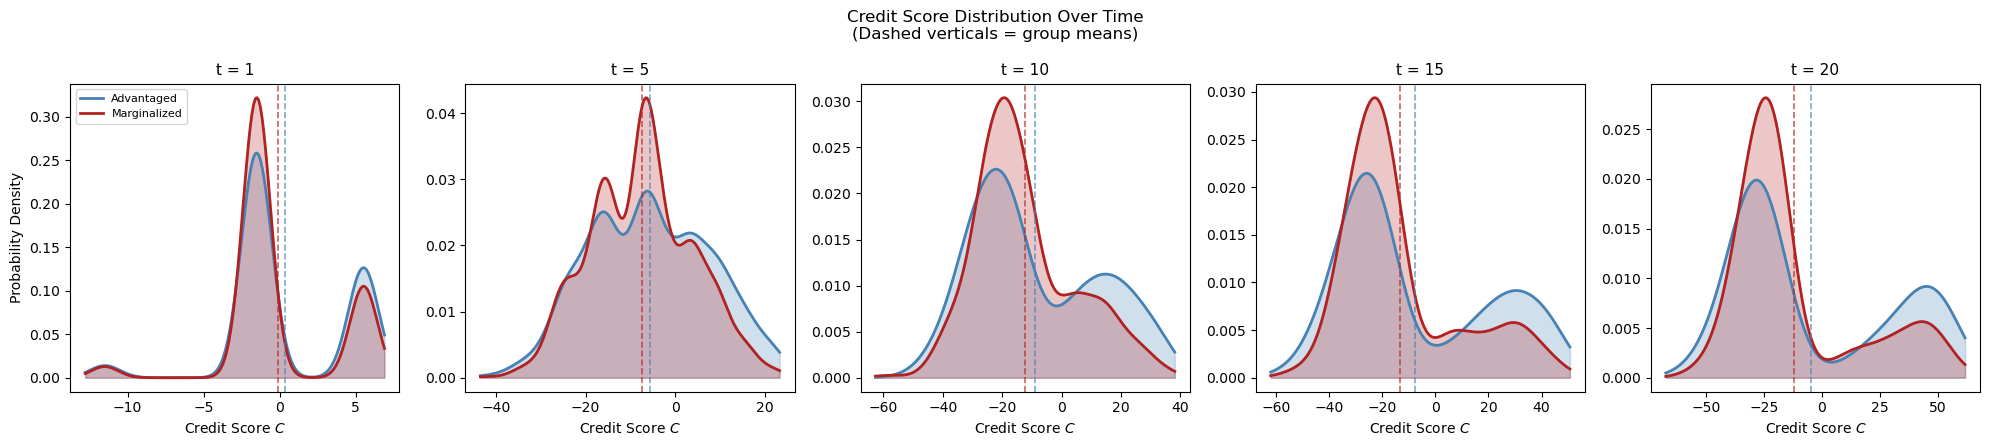

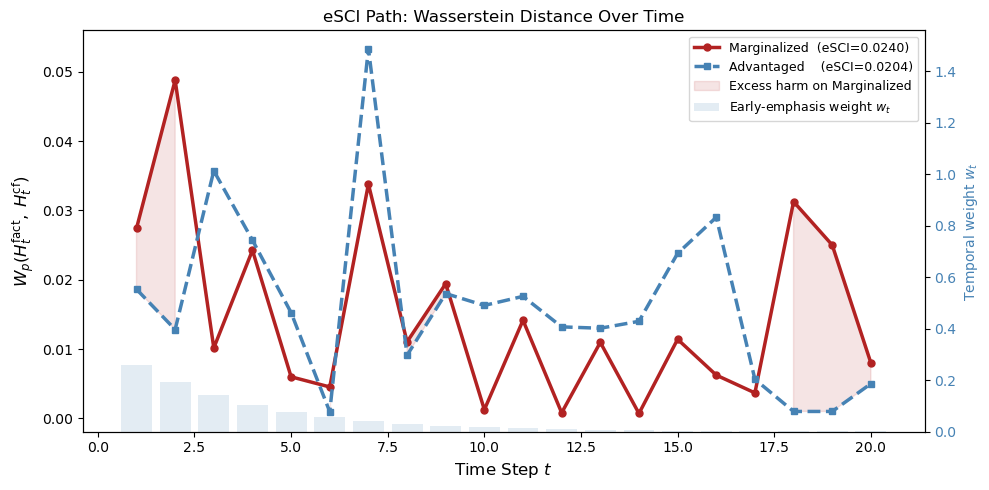


  eSCI (Advantaged)    = 0.0204
  eSCI (Marginalized)  = 0.0240


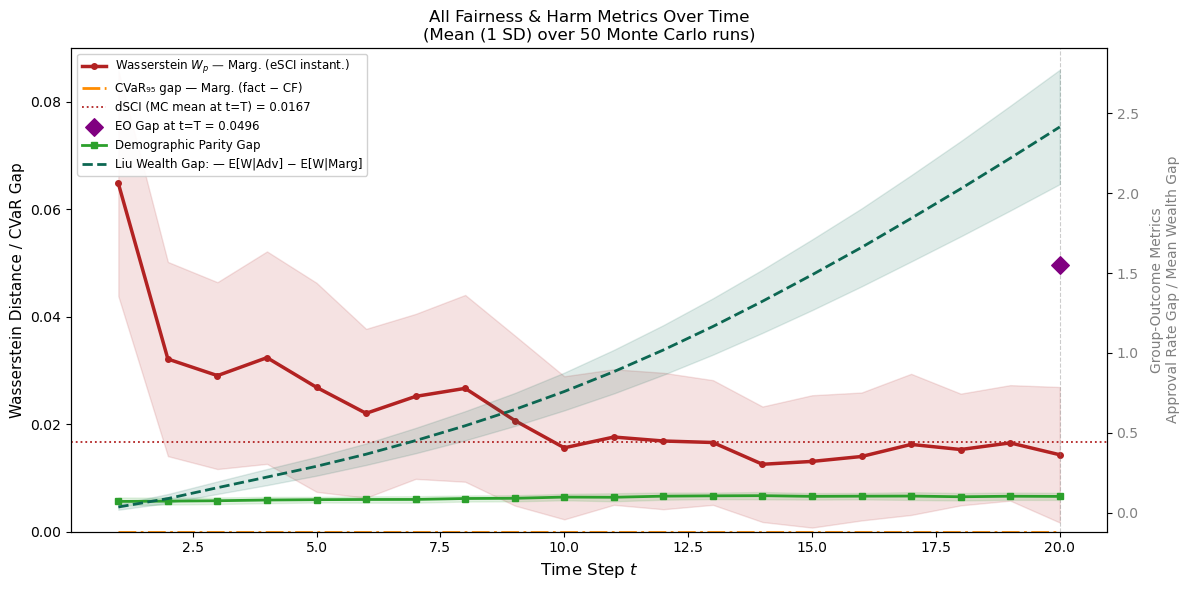

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.special import expit
from scipy.stats import wasserstein_distance, gaussian_kde

RNG_SEED = 905

N = 2000
T = 20
TAU = 0.5

G = np.array([1] * (N // 2) + [0] * (N // 2))

# starting distributions
MU_START      = np.array([0.65, 0.50])
SIGMA_STATE   = np.array([0.12, 0.08])

MU_A_ADV      = 1.0
MU_A_MARG     = 0.4
SIGMA_A_INIT  = 0.12

RHO_A         = 0.95
ALPHA_A       = 0.3
SIGMA_A_NOISE = 0.05

# decision model
INTERCEPT = -1.5
BETA_A    =  0.6
BETA_W    =  0.25

# VAR feedback
VAR_MATRIX = np.array([[0.90, 0.05],
                        [0.10, 0.85]])

BETA_INTERACTION  = 0.05
GAMMA_APPROVED    = np.array([+0.50,  +5.0])
GAMMA_DENIED      = np.array([-0.08,  -2.0])
POVERTY_TRAP_PENALTY = np.array([-0.80, -12.0])
VAR_NOISE_SIGMA   = 0.10

# harm weights
LAMBDA_FN = 1.0
LAMBDA_FP = 2.0

# eSCI
DECAY_LAMBDA = 0.3

N_MONTE_CARLO = 1000

def initialize_population(n, g, mu_start, sigma, mu_a_adv, mu_a_marg, sigma_a,
                           rng_local):
    S = np.zeros((n, 2))
    A = np.zeros(n)

    adv_mask  = (g == 1)
    marg_mask = (g == 0)

    S[adv_mask]  = rng_local.normal(mu_start, sigma,
                                    size=(int(adv_mask.sum()),  2))
    S[marg_mask] = rng_local.normal(mu_start, sigma,
                                    size=(int(marg_mask.sum()), 2))

    A[adv_mask]  = rng_local.normal(mu_a_adv,  sigma_a,
                                    size=int(adv_mask.sum()))
    A[marg_mask] = rng_local.normal(mu_a_marg, sigma_a,
                                    size=int(marg_mask.sum()))

    A            = np.clip(A, 0, None)
    S[:, 0]      = np.clip(S[:, 0], 0, None)

    Y = (S[:, 0] >= TAU).astype(int)
    return S, A, Y

def make_decisions(S, A, rng_local):
    logit = INTERCEPT + BETA_A * A + BETA_W * S[:, 0]
    prob  = expit(logit)
    Y_hat = rng_local.binomial(1, prob)
    return Y_hat, prob

def check_degeneracy(approval_rates, t, threshold=0.05):
    for g_val, label in zip([0, 1], ['Marginalized', 'Advantaged']):
        rate = approval_rates[g_val]
        if rate < threshold or rate > (1.0 - threshold):
            print(f"  WARNING [t={t}]: {label} approval rate = {rate:.3f} "
                  f"— potential ceiling/floor effect")

def compute_pointwise_harm(Y_hat, Y_true, W, tau,
                           lambda_fn=LAMBDA_FN, lambda_fp=LAMBDA_FP):
    harm    = np.zeros(len(Y_hat))

    fn_mask = (Y_hat == 0) & (Y_true == 1)
    harm[fn_mask] += lambda_fn

    fp_mask         = (Y_hat == 1) & (W < tau)
    depth_below_tau = np.maximum(tau - W, 0.0)
    harm[fp_mask]  += lambda_fp * depth_below_tau[fp_mask]

    return harm

def compute_harm_distribution(harm_values, group_mask):
    return harm_values[group_mask]

def var_feedback_transition(S, Y_hat, tau, rng_local):
    Y_hat_col   = Y_hat.reshape(-1, 1)

    S_ar          = S @ VAR_MATRIX.T
    S_interaction = BETA_INTERACTION * Y_hat_col * S

    gamma = np.where(Y_hat_col == 1, GAMMA_APPROVED, GAMMA_DENIED)

    poverty_trap_mask        = (Y_hat == 1) & (S[:, 0] < tau)
    gamma[poverty_trap_mask] = POVERTY_TRAP_PENALTY

    noise  = rng_local.normal(0.0, VAR_NOISE_SIGMA, size=S.shape)

    S_next          = S_ar + S_interaction + gamma + noise
    S_next[:, 0]    = np.clip(S_next[:, 0], 0, None)
    return S_next

def update_structural_attribute(A, Y_hat, W, tau, rng_local):
    successful_loan = (Y_hat == 1) & (W >= tau)
    noise  = rng_local.normal(0.0, SIGMA_A_NOISE, size=A.shape)
    A_new  = RHO_A * A + ALPHA_A * successful_loan.astype(float) + noise
    return np.clip(A_new, 0, None)

def counterfactual_intervention(A_factual, G, adv_mean_A):
    A_cf       = A_factual.copy()
    marg_mask  = (G == 0)
    gap        = adv_mean_A - A_cf[marg_mask].mean()
    A_cf[marg_mask] += gap
    return A_cf

def compute_dsci(harm_f_group, harm_cf_group):
    return float(wasserstein_distance(harm_f_group, harm_cf_group))

def compute_esci_path(harm_traj_f, harm_traj_cf, group_mask,
                      weighting='early_emphasis', decay_lambda=DECAY_LAMBDA):
    T_sim  = len(harm_traj_f)
    w_by_t = np.zeros(T_sim)

    for t in range(T_sim):
        h_f  = compute_harm_distribution(harm_traj_f[t],  group_mask)
        h_cf = compute_harm_distribution(harm_traj_cf[t], group_mask)
        w_by_t[t] = wasserstein_distance(h_f, h_cf)

    t_idx = np.arange(1, T_sim + 1, dtype=float)

    if weighting == 'uniform':
        weights = np.ones(T_sim)
    elif weighting == 'early_emphasis':
        weights = np.exp(-decay_lambda * (t_idx - 1))
    elif weighting == 'endpoint_emphasis':
        weights = t_idx / t_idx.sum()
    else:
        raise ValueError(f"Unknown weighting: {weighting}")

    weights         = weights / weights.sum()
    esci_path_value = float(np.sum(weights * w_by_t))
    return esci_path_value, w_by_t

def demographic_parity_gap(Y_hat, G):
    return float(abs(Y_hat[G == 1].mean() - Y_hat[G == 0].mean()))

def equalized_odds_gap(Y_hat, Y_true, G):
    for g_val in [0, 1]:
        mask = G == g_val
        if (Y_true[mask] == 1).sum() == 0 or (Y_true[mask] == 0).sum() == 0:
            return np.nan
    tpr = {g: Y_hat[(G == g) & (Y_true == 1)].mean() for g in [0, 1]}
    fpr = {g: Y_hat[(G == g) & (Y_true == 0)].mean() for g in [0, 1]}
    return float(max(abs(tpr[1] - tpr[0]), abs(fpr[1] - fpr[0])))

def liu_outcome_curve(W_history, G):
    T_sim = W_history.shape[0]
    curve = np.zeros((T_sim, 2))
    for t in range(T_sim):
        curve[t, 0] = W_history[t, G == 0].mean()
        curve[t, 1] = W_history[t, G == 1].mean()
    return curve

def liu_delta_mu(outcome_curve):
    return outcome_curve[-1] - outcome_curve[0]

def cvar(harm_samples, alpha=0.95):
    if len(harm_samples) == 0:
        return 0.0
    threshold = np.percentile(harm_samples, alpha * 100)
    tail      = harm_samples[harm_samples >= threshold]
    return float(tail.mean()) if len(tail) > 0 else 0.0

def tail_analysis(harm_f, harm_cf, group_name="Marginalized",
                  percentiles=(75, 90, 95, 99)):
    results = {}
    print(f"\n{'='*55}")
    print(f"  Tail Analysis — {group_name} Group")
    print(f"{'='*55}")
    for p in percentiles:
        q_f   = float(np.percentile(harm_f,  p))
        q_cf  = float(np.percentile(harm_cf, p))
        mass_f  = float(np.mean(harm_f  > q_f))
        mass_cf = float(np.mean(harm_cf > q_f))
        excess  = mass_f - mass_cf
        results[p] = {'factual_threshold': q_f,
                      'cf_threshold':      q_cf,
                      'excess_tail_mass':  excess}
        print(f"  P{p:>2d}: Factual={q_f:.4f}  CF={q_cf:.4f}  "
              f"Excess tail mass={excess:+.4f}")

    cvar_f  = cvar(harm_f)
    cvar_cf = cvar(harm_cf)
    results['cvar95'] = {'factual':       cvar_f,
                         'counterfactual': cvar_cf,
                         'gap':            cvar_f - cvar_cf}
    print(f"\n  CVaR_95 — Factual: {cvar_f:.4f} | CF: {cvar_cf:.4f} | "
          f"Gap: {cvar_f - cvar_cf:+.4f}")
    return results

def run_simulation(rng_local):
    S_f, A_f, _ = initialize_population(
        N, G, MU_START, SIGMA_STATE,
        MU_A_ADV, MU_A_MARG, SIGMA_A_INIT,
        rng_local
    )

    S_cf = S_f.copy()
    A_cf = A_f.copy()

    harm_traj_f   = []
    harm_traj_cf  = []
    W_history_f   = np.zeros((T, N))
    W_history_cf  = np.zeros((T, N))
    C_history_f   = np.zeros((T, N))   
    C_history_cf  = np.zeros((T, N))   
    approval_traj = {
        'factual': np.zeros((T, 2)),
        'cf':      np.zeros((T, 2))
    }

    for t in range(T):
        Y_true_f  = (S_f[:, 0]  >= TAU).astype(int)
        Y_true_cf = (S_cf[:, 0] >= TAU).astype(int)

        Y_hat_f,  _ = make_decisions(S_f,  A_f,  rng_local)

        adv_mean_A       = float(A_f[G == 1].mean())
        A_cf_intervened  = counterfactual_intervention(A_cf, G, adv_mean_A)
        Y_hat_cf, _      = make_decisions(S_cf, A_cf_intervened, rng_local)

        harm_f  = compute_pointwise_harm(Y_hat_f,  Y_true_f,  S_f[:, 0],  TAU)
        harm_cf = compute_pointwise_harm(Y_hat_cf, Y_true_cf, S_cf[:, 0], TAU)

        harm_traj_f.append(harm_f)
        harm_traj_cf.append(harm_cf)

        S_f  = var_feedback_transition(S_f,  Y_hat_f,  TAU, rng_local)
        S_cf = var_feedback_transition(S_cf, Y_hat_cf, TAU, rng_local)

        A_f  = update_structural_attribute(A_f,            Y_hat_f,  S_f[:, 0],  TAU, rng_local)
        A_cf = update_structural_attribute(A_cf_intervened, Y_hat_cf, S_cf[:, 0], TAU, rng_local)

        W_history_f[t]  = S_f[:, 0]
        W_history_cf[t] = S_cf[:, 0]
        C_history_f[t]  = S_f[:, 1]
        C_history_cf[t] = S_cf[:, 1]   

        for g_val in [0, 1]:
            approval_traj['factual'][t, g_val] = float(Y_hat_f[G  == g_val].mean())
            approval_traj['cf'][t, g_val]      = float(Y_hat_cf[G == g_val].mean())

        rates = {g_val: float(Y_hat_f[G == g_val].mean()) for g_val in [0, 1]}
        check_degeneracy(rates, t)

    return {
        'harm_traj_f':     harm_traj_f,
        'harm_traj_cf':    harm_traj_cf,
        'W_history_f':     W_history_f,
        'W_history_cf':    W_history_cf,
        'C_history_f':     C_history_f,    
        'C_history_cf':    C_history_cf,   
        'approval_traj':   approval_traj,
        'Y_hat_final_f':   Y_hat_f,
        'Y_hat_final_cf':  Y_hat_cf,
        'Y_true_final':    Y_true_f,
        'S_final_f':       S_f,
        'S_final_cf':      S_cf,
    }

def run_monte_carlo(n_runs=N_MONTE_CARLO):
    results = {
        'dsci':             np.zeros(n_runs),
        'esci_path':        np.zeros(n_runs),
        'dp_gap_final':     np.zeros(n_runs),
        'eo_gap_final':     np.zeros(n_runs),
        'liu_delta_marg':   np.zeros(n_runs),
        'liu_delta_adv':    np.zeros(n_runs),
        'cvar95_gap':       np.zeros(n_runs),
        'wasserstein_traj': np.zeros((n_runs, T)),
        'mean_W_traj_f':    np.zeros((n_runs, T)),
        'mean_W_traj_cf':   np.zeros((n_runs, T)),
        'mean_W_traj_adv_f':  np.zeros((n_runs, T)),
        'mean_W_traj_marg_f': np.zeros((n_runs, T)),
    }

    for run in range(n_runs):
        run_rng = np.random.default_rng(RNG_SEED + run)
        sim     = run_simulation(run_rng)

        marg_mask = (G == 0)
        adv_mask  = (G == 1)

        h_f_final  = compute_harm_distribution(sim['harm_traj_f'][-1],  marg_mask)
        h_cf_final = compute_harm_distribution(sim['harm_traj_cf'][-1], marg_mask)

        results['dsci'][run] = compute_dsci(h_f_final, h_cf_final)

        esci_val, w_traj = compute_esci_path(
            sim['harm_traj_f'], sim['harm_traj_cf'], marg_mask,
            weighting='early_emphasis'
        )
        results['esci_path'][run]        = esci_val
        results['wasserstein_traj'][run] = w_traj

        results['dp_gap_final'][run] = demographic_parity_gap(
            sim['Y_hat_final_f'], G)
        results['eo_gap_final'][run] = equalized_odds_gap(
            sim['Y_hat_final_f'], sim['Y_true_final'], G)

        liu_curve = liu_outcome_curve(sim['W_history_f'], G)
        delta     = liu_delta_mu(liu_curve)
        results['liu_delta_marg'][run] = float(delta[0])
        results['liu_delta_adv'][run]  = float(delta[1])

        results['cvar95_gap'][run] = cvar(h_f_final) - cvar(h_cf_final)

        results['mean_W_traj_f'][run]  = sim['W_history_f'].mean(axis=1)
        results['mean_W_traj_cf'][run] = sim['W_history_cf'].mean(axis=1)

        results['mean_W_traj_adv_f'][run]  = sim['W_history_f'][:, adv_mask].mean(axis=1)
        results['mean_W_traj_marg_f'][run] = sim['W_history_f'][:, marg_mask].mean(axis=1)

        if (run + 1) % 10 == 0:
            print(f"  Completed run {run + 1}/{n_runs}")

    return results

def plot_wealth_divergence(mean_W_traj_f, mean_W_traj_cf):
    t_axis = np.arange(1, T + 1)

    illus_rng  = np.random.default_rng(RNG_SEED)
    sim_illus  = run_simulation(illus_rng)
    W_f  = sim_illus['W_history_f']
    W_cf = sim_illus['W_history_cf']

    mean_W_adv_f   = W_f[:, G == 1].mean(axis=1)
    mean_W_marg_f  = W_f[:, G == 0].mean(axis=1)
    mean_W_adv_cf  = W_cf[:, G == 1].mean(axis=1)
    mean_W_marg_cf = W_cf[:, G == 0].mean(axis=1)

    mc_mean_f = mean_W_traj_f.mean(axis=0)
    mc_std_f  = mean_W_traj_f.std(axis=0)

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot(t_axis, mean_W_adv_f,   color='steelblue', lw=2.5,
            label='Advantaged — Factual')
    ax.plot(t_axis, mean_W_marg_f,  color='firebrick', lw=2.5,
            label='Marginalized — Factual')
    ax.plot(t_axis, mean_W_adv_cf,  color='steelblue', lw=1.5,
            linestyle='--', label='Advantaged — Counterfactual')
    ax.plot(t_axis, mean_W_marg_cf, color='firebrick', lw=1.5,
            linestyle='--', label='Marginalized — Counterfactual')

    ax.axhline(TAU, color='black', lw=1.2, linestyle=':',
               label=f'τ = {TAU}')

    ax.set_xlabel('Time Step $t$', fontsize=12)
    ax.set_ylabel('Mean Wealth $E[W_t | G=g]$', fontsize=12)
    ax.set_title(
        'Wealth Trajectories',
        fontsize=12
    )
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig('eq_start_wealth_divergence.png', dpi=150)
    plt.show()

def plot_approval_trajectories(approval_traj):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    labels = ['Marginalized (G=0)', 'Advantaged (G=1)']
    colors = ['firebrick', 'steelblue']
    worlds = [('factual', 'Factual World'), ('cf', 'Counterfactual World')]

    for ax, (key, title) in zip(axes, worlds):
        for g_idx, (label, color) in enumerate(zip(labels, colors)):
            ax.plot(range(1, T + 1), approval_traj[key][:, g_idx],
                    label=label, color=color, lw=2, marker='o', markersize=3)
        ax.axhline(0.05, color='gray', linestyle='--', alpha=0.5, lw=1)
        ax.axhline(0.95, color='gray', linestyle='--', alpha=0.5, lw=1,
                   label='Ceiling/floor threshold')
        ax.set_ylim(0, 1)
        ax.set_xlabel('Time Step $t$')
        ax.set_ylabel('P(Ŷ=1 | G)')
        ax.set_title(title)
        ax.legend(fontsize=8)

    plt.suptitle('Approval Rate Trajectories', fontsize=13)
    plt.tight_layout()
    plt.savefig('eq_start_approval_traj.png', dpi=150)
    plt.show()

def plot_harm_distributions(harm_f_final, harm_cf_final,
                            group_name="Marginalized"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    x_max   = max(harm_f_final.max(), harm_cf_final.max()) + 0.1
    x_range = np.linspace(0, x_max, 400)

    ax = axes[0]
    kde_f  = gaussian_kde(harm_f_final  + 1e-9)(x_range)
    kde_cf = gaussian_kde(harm_cf_final + 1e-9)(x_range)
    ax.plot(x_range, kde_f,  label='Factual',        color='firebrick',  lw=2)
    ax.plot(x_range, kde_cf, label='Counterfactual', color='steelblue',  lw=2,
            linestyle='--')
    ax.set_xlabel('Individual Harm $u_i$')
    ax.set_ylabel('Density')
    ax.set_title(f'Harm Distribution — {group_name} Group')
    ax.legend()

    ax2          = axes[1]
    tail_thr     = float(np.percentile(harm_f_final, 75))
    tail_range   = x_range[x_range >= tail_thr]
    if len(tail_range) > 5:
        ax2.plot(tail_range,
                 gaussian_kde(harm_f_final  + 1e-9)(tail_range),
                 label='Factual',        color='firebrick', lw=2)
        ax2.plot(tail_range,
                 gaussian_kde(harm_cf_final + 1e-9)(tail_range),
                 label='Counterfactual', color='steelblue', lw=2,
                 linestyle='--')
    ax2.set_xlabel('Individual Harm $u_i$')
    ax2.set_title(f'Tail (Top 25%) — {group_name} Group')
    ax2.legend()

    plt.suptitle(f'Factual vs. Counterfactual Harm\n'
                 f'({group_name} group)', fontsize=12)
    plt.tight_layout()
    plt.savefig('eq_start_harm_dist.png', dpi=150)
    plt.show()

def plot_wasserstein_trajectory(mean_w_traj, std_w_traj=None):
    t_idx   = np.arange(1, T + 1, dtype=float)
    weights = np.exp(-DECAY_LAMBDA * (t_idx - 1))
    weights /= weights.sum()

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(t_idx, mean_w_traj, color='firebrick', lw=2, marker='o',
            markersize=4,
            label=r'$W_p(H_t^{\mathrm{fact}},\ H_t^{\mathrm{cf}})$')
    if std_w_traj is not None:
        ax.fill_between(t_idx,
                        mean_w_traj - std_w_traj,
                        mean_w_traj + std_w_traj,
                        alpha=0.2, color='firebrick', label='1 SD')

    ax2 = ax.twinx()
    ax2.bar(t_idx, weights, alpha=0.18, color='steelblue',
            label='Early-emphasis weight $w_t$')
    ax2.set_ylabel('Temporal weight $w_t$', color='steelblue', fontsize=10)
    ax2.tick_params(axis='y', labelcolor='steelblue')

    ax.set_xlabel('Time Step $t$')
    ax.set_ylabel('Wasserstein Distance')
    ax.set_title('eSCI Path: Wasserstein Distance Over Time'
                 , fontsize=12)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
    plt.tight_layout()
    plt.savefig('eq_start_wasserstein_traj.png', dpi=150)
    plt.show()

def plot_dp_gap_trajectory(approval_traj_mc):
    illus_rng = np.random.default_rng(RNG_SEED + 999)
    sim_dp    = run_simulation(illus_rng)
    dp_over_t = np.abs(
        sim_dp['approval_traj']['factual'][:, 1] -
        sim_dp['approval_traj']['factual'][:, 0]
    )

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(range(1, T + 1), dp_over_t, color='#4C72B0', lw=2, marker='s',
            markersize=4, label='DP Gap over time')
    ax.axhline(0.05, color='gray', linestyle='--', lw=1,
               label='Threshold = 0.05')
    ax.set_xlabel('Time Step $t$')
    ax.set_ylabel('|P(Ŷ=1|G=1) − P(Ŷ=1|G=0)|')
    ax.set_title('Demographic Parity Gap Over Time\n',
                 fontsize=12)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig('eq_start_dp_over_time.png', dpi=150)
    plt.show()
    return dp_over_t

def print_results_table(mc_res):
    def fmt(arr):
        a = np.asarray(arr, dtype=float)
        return f"{a.mean():.4f} ± {a.std():.4f}"

    print("\n" + "=" * 65)
    print("  All Metrics")
    print("  (mean ± SD over Monte Carlo runs)")
    print("=" * 65)
    print(f"  dSCI  (Wasserstein at t=T)              : {fmt(mc_res['dsci'])}")
    print(f"  eSCI_path (early-emphasis)              : {fmt(mc_res['esci_path'])}")
    print(f"  CVaR_95 gap  (factual − counterfactual) : {fmt(mc_res['cvar95_gap'])}")
    print("-" * 65)
    print("  STATIC METRICS  (cross-sectional, evaluated at t=T)")
    print(f"  Demographic Parity Gap                  : {fmt(mc_res['dp_gap_final'])}")
    print(f"  Equalized Odds Gap                      : {fmt(mc_res['eo_gap_final'])}")
    print("-" * 65)
    print("  LIU ET AL. (2018) DYNAMIC COMPARATOR")
    print(f"  Δμ_marginalized (wealth change t=0→T)   : {fmt(mc_res['liu_delta_marg'])}")
    print(f"  Δμ_advantaged   (wealth change t=0→T)   : {fmt(mc_res['liu_delta_adv'])}")
    print("=" * 65)

def plot_wealth_distribution_over_time(W_history_f, G,
                                        timesteps_to_plot=(0, 4, 9, 14, 19)):
    adv_mask  = (G == 1)
    marg_mask = (G == 0)

    n_steps = len(timesteps_to_plot)
    fig, axes = plt.subplots(1, n_steps, figsize=(4 * n_steps, 4.5),
                             sharey=False)

    alpha_levels = np.linspace(0.5, 1.0, n_steps)

    for col, (t_idx, alpha) in enumerate(zip(timesteps_to_plot, alpha_levels)):
        ax = axes[col]
        w_adv  = W_history_f[t_idx, adv_mask]
        w_marg = W_history_f[t_idx, marg_mask]

        x_min = min(w_adv.min(), w_marg.min()) - 0.05
        x_max = max(w_adv.max(), w_marg.max()) + 0.05
        x_range = np.linspace(x_min, x_max, 400)

        kde_adv  = gaussian_kde(w_adv)(x_range)
        kde_marg = gaussian_kde(w_marg)(x_range)

        ax.plot(x_range, kde_adv,  color='steelblue', lw=2,
                label='Advantaged')
        ax.fill_between(x_range, kde_adv,  alpha=0.25, color='steelblue')

        ax.plot(x_range, kde_marg, color='firebrick', lw=2,
                label='Marginalized')
        ax.fill_between(x_range, kde_marg, alpha=0.25, color='firebrick')

        ax.axvline(TAU, color='black', lw=1.2, linestyle=':',
                   label=f'τ={TAU}')
        ax.axvline(w_adv.mean(),  color='steelblue', lw=1.2,
                   linestyle='--', alpha=0.7)
        ax.axvline(w_marg.mean(), color='firebrick',  lw=1.2,
                   linestyle='--', alpha=0.7)

        ax.set_title(f't = {t_idx + 1}', fontsize=11)
        ax.set_xlabel('Wealth $W$', fontsize=10)
        if col == 0:
            ax.set_ylabel('Probability Density', fontsize=10)
            ax.legend(fontsize=8)

    fig.suptitle(
        'Wealth Distribution Over Time\n'
        '(Dashed verticals = group means; dotted = τ)',
        fontsize=12
    )
    plt.tight_layout()
    plt.savefig('eq_start_wealth_dist_over_time.png', dpi=150)
    plt.show()

def plot_credit_distribution_over_time(C_history_f, G,
                                        timesteps_to_plot=(0, 4, 9, 14, 19)):
    adv_mask  = (G == 1)
    marg_mask = (G == 0)

    n_steps = len(timesteps_to_plot)
    fig, axes = plt.subplots(1, n_steps, figsize=(4 * n_steps, 4.5),
                             sharey=False)

    for col, t_idx in enumerate(timesteps_to_plot):
        ax = axes[col]
        c_adv  = C_history_f[t_idx, adv_mask]
        c_marg = C_history_f[t_idx, marg_mask]

        # guard against degenerate distributions
        if c_adv.std() < 1e-6 or c_marg.std() < 1e-6:
            ax.set_title(f't = {t_idx + 1}\n(degenerate)', fontsize=10)
            continue

        x_min  = min(c_adv.min(), c_marg.min()) - 1.0
        x_max  = max(c_adv.max(), c_marg.max()) + 1.0
        x_range = np.linspace(x_min, x_max, 400)

        kde_adv  = gaussian_kde(c_adv)(x_range)
        kde_marg = gaussian_kde(c_marg)(x_range)

        ax.plot(x_range, kde_adv,  color='steelblue', lw=2,
                label='Advantaged')
        ax.fill_between(x_range, kde_adv,  alpha=0.25, color='steelblue')

        ax.plot(x_range, kde_marg, color='firebrick', lw=2,
                label='Marginalized')
        ax.fill_between(x_range, kde_marg, alpha=0.25, color='firebrick')

        ax.axvline(c_adv.mean(),  color='steelblue', lw=1.2,
                   linestyle='--', alpha=0.7)
        ax.axvline(c_marg.mean(), color='firebrick',  lw=1.2,
                   linestyle='--', alpha=0.7)

        ax.set_title(f't = {t_idx + 1}', fontsize=11)
        ax.set_xlabel('Credit Score $C$', fontsize=10)
        if col == 0:
            ax.set_ylabel('Probability Density', fontsize=10)
            ax.legend(fontsize=8)

    fig.suptitle(
        'Credit Score Distribution Over Time\n'
        '(Dashed verticals = group means)',
        fontsize=12
    )
    plt.tight_layout()
    plt.savefig('eq_start_credit_dist_over_time.png', dpi=150)
    plt.show()

def plot_esci_both_groups(harm_traj_f, harm_traj_cf, G,
                           weighting='early_emphasis',
                           decay_lambda=DECAY_LAMBDA):
    adv_mask  = (G == 1)
    marg_mask = (G == 0)

    t_count = len(harm_traj_f)
    t_idx   = np.arange(1, t_count + 1, dtype=float)

    w_adv  = np.zeros(t_count)
    w_marg = np.zeros(t_count)

    for t in range(t_count):
        h_f_adv   = compute_harm_distribution(harm_traj_f[t],  adv_mask)
        h_cf_adv  = compute_harm_distribution(harm_traj_cf[t], adv_mask)
        h_f_marg  = compute_harm_distribution(harm_traj_f[t],  marg_mask)
        h_cf_marg = compute_harm_distribution(harm_traj_cf[t], marg_mask)

        w_adv[t]  = wasserstein_distance(h_f_adv,  h_cf_adv)
        w_marg[t] = wasserstein_distance(h_f_marg, h_cf_marg)

    if weighting == 'early_emphasis':
        weights = np.exp(-decay_lambda * (t_idx - 1))
    elif weighting == 'uniform':
        weights = np.ones(t_count)
    elif weighting == 'endpoint_emphasis':
        weights = t_idx / t_idx.sum()
    else:
        raise ValueError(f"Unknown weighting: {weighting}")
    weights = weights / weights.sum()

    esci_adv  = float(np.sum(weights * w_adv))
    esci_marg = float(np.sum(weights * w_marg))

    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax2 = ax1.twinx()
    ax2.bar(t_idx, weights, color='steelblue', alpha=0.15,
            label='Early-emphasis weight $w_t$', zorder=1)
    ax2.set_ylabel('Temporal weight $w_t$', color='steelblue', fontsize=10)
    ax2.tick_params(axis='y', labelcolor='steelblue')
    ax2.set_ylim(0, weights.max() * 6)   # push bars low so lines are prominent

    ax1.plot(t_idx, w_marg, color='firebrick', lw=2.5, marker='o',
             markersize=5, zorder=3,
             label=f'Marginalized  (eSCI={esci_marg:.4f})')
    ax1.plot(t_idx, w_adv,  color='steelblue', lw=2.5, marker='s',
             markersize=5, zorder=3, linestyle='--',
             label=f'Advantaged    (eSCI={esci_adv:.4f})')

    ax1.fill_between(t_idx, w_marg, w_adv,
                     where=(w_marg >= w_adv),
                     alpha=0.12, color='firebrick',
                     label='Excess harm on Marginalized')

    ax1.set_xlabel('Time Step $t$', fontsize=12)
    ax1.set_ylabel(r'$W_p(H_t^{\mathrm{fact}},\; H_t^{\mathrm{cf}})$',
                   fontsize=12)
    ax1.set_title(
        'eSCI Path: Wasserstein Distance Over Time',
        fontsize=12
    )
    ax1.set_zorder(ax2.get_zorder() + 1)
    ax1.patch.set_visible(False)

    # combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper right')

    plt.tight_layout()
    plt.savefig('eq_start_esci_both_groups.png', dpi=150)
    plt.show()

    return esci_adv, esci_marg

def plot_all_metrics_over_time(mc_results, G,
                                n_mc_detail=50,
                                rng_seed=RNG_SEED):
    adv_mask  = (G == 1)
    marg_mask = (G == 0)

    dp_mat         = np.zeros((n_mc_detail, T))
    wass_marg_mat  = np.zeros((n_mc_detail, T))
    wealth_gap_mat = np.zeros((n_mc_detail, T))
    cvar_gap_mat   = np.zeros((n_mc_detail, T))
    eo_mat         = np.full((n_mc_detail, T), np.nan)

    for run in range(n_mc_detail):
        run_rng = np.random.default_rng(rng_seed + run)
        sim     = run_simulation(run_rng)

        approval_f = sim['approval_traj']['factual']   # (T, 2)

        for t in range(T):
            # DP Gap
            dp_mat[run, t] = float(abs(
                approval_f[t, 1] - approval_f[t, 0]
            ))

            # Wasserstein (instantaneous eSCI)
            h_f_m  = compute_harm_distribution(sim['harm_traj_f'][t],  marg_mask)
            h_cf_m = compute_harm_distribution(sim['harm_traj_cf'][t], marg_mask)
            wass_marg_mat[run, t] = wasserstein_distance(h_f_m, h_cf_m)

            # Liu Wealth Gap: E[W|Adv] − E[W|Marg] at each t
            wealth_gap_mat[run, t] = (
                sim['W_history_f'][t, adv_mask].mean() -
                sim['W_history_f'][t, marg_mask].mean()
            )

            # CVaR_95 gap (marginalized, factual vs CF)
            cvar_gap_mat[run, t] = cvar(h_f_m) - cvar(h_cf_m)

        # EO gap — only available at final t from stored Y_hat_final
        eo_mat[run, T - 1] = equalized_odds_gap(
            sim['Y_hat_final_f'], sim['Y_true_final'], G
        )

    def ms(arr):
        return arr.mean(axis=0), arr.std(axis=0)

    dp_mean,  dp_std  = ms(dp_mat)
    wm_mean,  wm_std  = ms(wass_marg_mat)
    wg_mean,  wg_std  = ms(wealth_gap_mat)
    cv_mean,  cv_std  = ms(cvar_gap_mat)
    eo_final_mean     = float(np.nanmean(eo_mat[:, T - 1]))

    dsci_mean = float(mc_results['dsci'].mean())
    t_axis    = np.arange(1, T + 1)

    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax2 = ax1.twinx()

    def _band(ax, t, mean, std, color, label, ls='-', lw=2, marker=None):
        ax.plot(t, mean, color=color, lw=lw, linestyle=ls,
                marker=marker, markersize=4, label=label)
        ax.fill_between(t, mean - std, mean + std,
                        alpha=0.13, color=color)

    _band(ax1, t_axis, wm_mean, wm_std,
          'firebrick', r'Wasserstein $W_p$ — Marg. (eSCI instant.)',
          lw=2.5, marker='o')
    _band(ax1, t_axis, cv_mean, cv_std,
          'darkorange', 'CVaR₉₅ gap — Marg. (fact − CF)',
          ls='-.', lw=2)

    # dSCI as horizontal reference line
    ax1.axhline(dsci_mean, color='firebrick', lw=1.3, linestyle=':',
                label=f'dSCI (MC mean at t=T) = {dsci_mean:.4f}')

    # EO gap — single marker at t=T
    ax1.scatter([T], [eo_final_mean], color='purple', zorder=5,
                s=80, marker='D',
                label=f'EO Gap at t=T = {eo_final_mean:.4f}')

    ax1.set_ylabel('Wasserstein Distance / CVaR Gap', fontsize=11, color='black')
    ax1.set_ylim(bottom=0)

    _band(ax2, t_axis, dp_mean, dp_std,
          '#2ca02c', 'Demographic Parity Gap', lw=2, marker='s')
    _band(ax2, t_axis, wg_mean, wg_std,
          '#0c6752', 'Liu Wealth Gap: — E[W|Adv] − E[W|Marg]',
          ls='--', lw=2)

    ax2.set_ylabel(
        'Group-Outcome Metrics\n'
        'Approval Rate Gap / Mean Wealth Gap',
        fontsize=10, color='gray', labelpad=8
    )
    ax2.tick_params(axis='y', labelcolor='gray')

    lines1, labs1 = ax1.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labs1 + labs2,
               fontsize=8.5, loc='upper left',
               framealpha=0.9)

    ax1.set_xlabel('Time Step $t$', fontsize=12)
    ax1.set_title(
        'All Fairness & Harm Metrics Over Time\n'
        f'(Mean (1 SD) over {n_mc_detail} Monte Carlo runs)',
        fontsize=12
    )
    ax1.axvline(T, color='gray', lw=0.8, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.savefig('all_metrics_over_time.png', dpi=150)
    plt.show()

if __name__ == "__main__":

    print("=" * 65)
    print(f"  N={N}  T={T}  MC runs={N_MONTE_CARLO}")
    print(f"  Initial wealth: BOTH groups ~ N({MU_START[0]}, {SIGMA_STATE[0]}²)")
    print(f"  Structural A: Adv ~ N({MU_A_ADV}, {SIGMA_A_INIT}²)  "
          f"Marg ~ N({MU_A_MARG}, {SIGMA_A_INIT}²)")
    print("=" * 65)

    print("\n--- Single illustrative run ---")
    single_rng = np.random.default_rng(RNG_SEED)
    sim_single = run_simulation(single_rng)

    marg_mask = (G == 0)

    plot_approval_trajectories(sim_single['approval_traj'])

    h_f_final  = compute_harm_distribution(sim_single['harm_traj_f'][-1],  marg_mask)
    h_cf_final = compute_harm_distribution(sim_single['harm_traj_cf'][-1], marg_mask)

    plot_harm_distributions(h_f_final, h_cf_final)
    tail_analysis(h_f_final, h_cf_final, group_name="Marginalized")

    liu_curve_f  = liu_outcome_curve(sim_single['W_history_f'],  G)
    liu_curve_cf = liu_outcome_curve(sim_single['W_history_cf'], G)

    _, w_traj_single = compute_esci_path(
        sim_single['harm_traj_f'], sim_single['harm_traj_cf'],
        marg_mask, weighting='early_emphasis'
    )
    plot_wasserstein_trajectory(w_traj_single)

    # Monte Carlo
    print("\n--- Monte Carlo simulation ---")
    mc_results = run_monte_carlo(N_MONTE_CARLO)

    plot_wealth_divergence(
        mc_results['mean_W_traj_f'],
        mc_results['mean_W_traj_cf']
    )

    mean_w_traj = mc_results['wasserstein_traj'].mean(axis=0)
    std_w_traj  = mc_results['wasserstein_traj'].std(axis=0)
    plot_wasserstein_trajectory(mean_w_traj, std_w_traj)

    dp_traj = plot_dp_gap_trajectory(mc_results)

    print_results_table(mc_results)

    timesteps = (0, 4, 9, 14, 19)

    plot_wealth_distribution_over_time(
        sim_single['W_history_f'], G,
        timesteps_to_plot=timesteps
    )

    plot_credit_distribution_over_time(
        sim_single['C_history_f'], G,
        timesteps_to_plot=timesteps
    )

    esci_adv_val, esci_marg_val = plot_esci_both_groups(
        sim_single['harm_traj_f'],
        sim_single['harm_traj_cf'],
        G
    )
    print(f"\n  eSCI (Advantaged)    = {esci_adv_val:.4f}")
    print(f"  eSCI (Marginalized)  = {esci_marg_val:.4f}")

    plot_all_metrics_over_time(mc_results, G, n_mc_detail=50)
